# [Title]

## Preparation

- [Github link](https://github.com/mixedmint/DSSS)

- Number of words: ***

- Runtime: *** hours (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: Podman

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **watermark**: A Jupyter Notebook extension for printing timestamps, version numbers, and hardware information.
    - ......

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## Introduction

[[ go back to the top ]](#Table-of-contents)

In [1]:
import time
start_time = time.time()

In [2]:
import pandas as pd
pd.set_option('display.float_format', lambda x: '%.2f' % x)
import numpy as np
from matplotlib import pyplot 
import matplotlib.pyplot as plt

## Research questions

[[ go back to the top ]](#Table-of-contents)

- RQ1 (预测能力)：在伦敦 Ward 层级上，社会人口统计与建成环境等特征在多大程度上能够准确预测不同学龄（Reception 与 Year 6）儿童的肥胖率？（VIF→MLR→RF/XGBoost）

- RQ2 (特征归因与解释)：在最优的预测模型中，哪些特征对儿童肥胖率具有最显著的驱动作用？这些关键特征的边际影响（Marginal effects）是如何具体表现的？（SHAP）

## Data

[[ go back to the top ]](#Table-of-contents)

### Data Source
介绍数据库：来源，link，有多少数据
#### Dependent Variables: Childhood Obesity Prevalence
In this project, I will use the [Prevalence of Childhood Obesity](https://data.london.gov.uk/dataset/prevalence-of-childhood-obesity-borough-ward-and-msoa-23g07/) at wards level in London from 2010 to 2013 as the dependent variable. This dataset provides the 数量和percentage of 两种儿童，超重和肥胖, 在london wards层面共计600+条原始数据。 

#### Independent Features
本project中，[London Ward Atlas dataset](https://data.london.gov.uk/dataset/ward-profiles-and-atlas-exprl/)被选为挑选features的基础数据集。该数据集涵盖了自2001年（？）到xxxx年的ward人口统计及相关数据，涉及人口、多样性、家庭数量、预期寿命、住房、犯罪、福利、土地利用、贫困程度和就业等方面。共计xxx个变量/columns，xxx个samples/rows。因数据全面涉及面广（？），适用于features初筛。

在特征初步筛选方面，为childhood obesity预测选择features一直缺乏统一标准。写两条综述：1. mazza (2025) 从统计学指标（每个写一两个我用到的feature）、社会指标、经济指标和其他一般性指标四个角度，为回归预测选择特征，这也是大多数学者考虑的角度。2. 在此基础上，Salerno (2024）还选取了Health behavior and condition和Environmental Exposure两个角度的指标，考虑到了个体行为和外部建成环境因素，拓宽了视角。基于以上两篇文献，本文将从……四个角度初步挑选特征，计划得到的具体特征如下：表格

指标框架

四个方面：Salerno, P.R.V.O. et al. (2024) ‘County-level socio-environmental factors and obesity prevalence in the United States’, Diabetes, Obesity and Metabolism, 26(5), pp. 1766–1774. Available at: https://doi.org/10.1111/dom.15488.

具体指标：
1. 该研究纳入了14项人口统计学指标（中位年龄、抚养比、拥有4个或以上子女的家庭比例）、社会指标（25-54岁人群的平均受教育年限、25-54岁人群的学历持有率）、经济指标（15岁及以上人群的工资和收入者比例、25-54岁无工作收入女性的比例、工资和收入超过平均工资两倍的人群比例、低于最低工资标准的人群比例、领取收入补助和老年养老金补贴的人群比例）以及其他一般性指标（人均月收入、机动车保有率、平均车辆牌照费和平均出国天数）。

   Mazza, O. et al. (2025) ‘Spatial patterns of childhood obesity clusters linked to socioeconomic inequalities’, Frontiers in Public Health, 13. Available at: https://doi.org/10.3389/fpubh.2025.1497090.

2. 桌面上的图（domegraphic）

Hammond R. et al. (2019) ‘Predicting childhood obesity using electronic health records and publicly available data’, PLOS ONE, 14(4), p. e0215571. Available at: https://doi.org/10.1371/journal.pone.0215571.

3. 其他三个方面：Salerno, P.R.V.O. et al. (2024)

| Variable                            | Type         | Description                                                             |Year   |
|-------------------------------------|--------------|-------------------------------------------------------------------------|---|
|**Dependent Variable** |  |  |  |
| Childhood obesity rate: reception (aged 4-5 years) and year 6 (aged 10-11 years) | Numeric | The children obesity rate of wards  | 2010-2013 |
| | | | |
| **Demographic Features** |   |                                     |   |
| Median age | Numeric | Median age of wards | 2011 |
| Population under 15 years | Numeric | Percentage of population age 15 years or younger | 2013 |
| Population density | Numeric | Population density (persons per sq km) | 2011 |
| White population | Numeric | Percentage of White population | 2011 |
| Population borned in UK  | Numeric  | Percentage of population borned in UK                                    | 2011  |
| | | | |
| **Health Condition Features**  |   |                                   |  |
| Life expectancy  | Numeric  | Average life expectancy at birth of all genders | 2009-2013  |
| Subjective well-being average score  | Numeric | Subjective well-being average score of wards | 2011-2013 |
| People with Bad or Very Bad Health | Numeric | Percentage of people with Bad or Very Bad Health | 2011 |
| | | | |
| **Socioeconomic Features**  |   |                                   |   |
| Median house price | Numeric | The median house price (UK pounds) of wards | 2011 |
| Homeownership | Numeric | Percentage of owner-occupied housing units | 2011 |
| Median household income | Numeric | The income (UK pound) where half of households in a county earn more and half of households earn less | 2012 |
| Children in Single-Parent Household | Numeric  | Percentage of children that live in a household headed by a single parent | 2011 |
| Parents unempolyment | Numeric | Percentage of households with no adults in employment with dependent children | 2011 |
| Higher education qulifications | Numeric | Percentage of people with level 4 qulifications and above | 2011 |
| Housing benefits claimants | Numeric | Percentage of households that claim housing benefits | 2011 |
| Children in poverty | Numeric | Percentage of people under age 16 in poverty | 2011 |
| Crime rate | Numeric | Crime rate of wards | 2011 |
| Indices of Deprivation | Numeric | Average scores of Indices of Deprivation | 2010 |
| Income Deprivation Affecting Children Index (IDACI) | Numeric | Average scores of IDACI | 2010 |
| | | | |
| **Environmental Exposure Features**  |   |                                   |  |
| Air emissions | Numeric  | Annual Mean of Nitrogen Oxide (NOx) | 2011  |
| Deficiency in access to green space | Numeric | Percentage of homes with deficiency in access to nature | 2012 |
| Public Transport Accessibility | Numeric | Average PTAL score | 2011 |
| Car access | Numeric | Cars per household | 2011 |

共23个features

### Data Pre-processing and Data Presentation
流程如下

1.	读取数据：分别导入已经过筛选的原始数据 $X$ 和 $y$。
2.	格式化目标变量 ($y$)：重命名，强制转换为数值型（errors='coerce'），删除带有 NaN 的行。
3.	特征工程 ($X$)：重命名，计算各项所需比例，丢弃原始绝对数值列，检查并处理潜在的 NaN。
4.	数据合并：根据 Ward Code 使用 inner join 合并 $X$ 和 $y$。
5.	探索性数据分析 (EDA)：打印合并后数据集的描述性统计（.describe()），绘制直方图、散点图或空间分布地图。
#### Childhood Obesity Prevalance

In [3]:
# Load childhood obesity prvalance data
obesity = pd.read_csv("https://raw.githubusercontent.com/mixedmint/DSSS/refs/heads/main/data/children_obesity_2010-2013.csv")
obesity.head(10)

,Code,Borough,Names,obesity rate % (age 4-5),obesity rate % (age 10-11)
0,E05000001,City of London,Aldersgate,s,s
1,E05000015,City of London,Cripplegate,s,s
2,E05000017,City of London,Farringdon Within,s,s
3,E05000021,City of London,Portsoken,s,s
4,E05000026,Barking and Dagenham,Abbey,15.1%,23.2%
5,E05000027,Barking and Dagenham,Alibon,9.6%,25.6%
6,E05000028,Barking and Dagenham,Becontree,12.1%,28.4%
7,E05000029,Barking and Dagenham,Chadwell Heath,12.1%,28.8%
8,E05000030,Barking and Dagenham,Eastbrook,10.9%,24.1%
9,E05000031,Barking and Dagenham,Eastbury,12.3%,24.3%


In [4]:
obesity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 628 entries, 0 to 627
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Code                        628 non-null    object
 1   Borough                     628 non-null    object
 2   Names                       628 non-null    object
 3   obesity rate % (age 4-5)    628 non-null    object
 4   obesity rate % (age 10-11)  628 non-null    object
dtypes: object(5)
memory usage: 24.7+ KB


We noticed that 原始数据用`s`表示Suppressed（因样本量过小为了保护隐私而被隐藏），且obesity rate columns类型为object而非float。我们需要删掉带有NaN值的行，并对obesity rates columns进行数值类型转换。

In [5]:
# First, simplify complex column names
obesity = obesity.rename({'obesity rate % (age 4-5)': 'Reception', 'obesity rate % (age 10-11)': 'Year 6'}, axis=1)

# Then convert obesity rate columns from strings to floats
cols_to_clean = ['Reception', 'Year 6']
for col in cols_to_clean:
    obesity[col] = pd.to_numeric(obesity[col].str.replace('%', ''), errors='coerce')

# Drop rows with NaN values and Borough column
obesity = obesity.dropna().drop(['Borough'], axis=1)

obesity.head()

,Code,Names,Reception,Year 6
4,E05000026,Abbey,15.10,23.20
5,E05000027,Alibon,9.60,25.60
6,E05000028,Becontree,12.10,28.40
7,E05000029,Chadwell Heath,12.10,28.80
8,E05000030,Eastbrook,10.90,24.10


In [6]:
# Check data types of obesity rates after processing
obesity.info()

<class 'pandas.core.frame.DataFrame'>
Index: 609 entries, 4 to 626
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Code       609 non-null    object 
 1   Names      609 non-null    object 
 2   Reception  609 non-null    float64
 3   Year 6     609 non-null    float64
dtypes: float64(2), object(2)
memory usage: 23.8+ KB


The obesity rates columns have been successfully transfered into float types.
#### Features

In [7]:
# Load features data
raw_features = pd.read_csv("https://raw.githubusercontent.com/mixedmint/DSSS/refs/heads/main/data/selected_ward_atlas.csv")
raw_features.head()

,New Code,Borough,Names,Median age,Aged 0-15,Population density,White,Mixed,Asian or Asian British,Black or Black British,...,% Highest level of qualification: Level 4 qualifications and above,Housing benefits claimants,Children in poverty,Crime rate,Air emissions,% homes with deficiency in access to nature,Public transport accessibility,Car access,Indices of Deprivation,IDACI
0,E09000001,City of London,City of London,39,7.50,2312.50,5799,289,940,193,...,68.40,6.46,13.90,611.90,94.87,100.00,7.68,0.39,12.12,0.12
1,E05000026,Barking and Dagenham,Abbey,29,25.27,9884.62,3596,585,5619,2621,...,34.50,15.20,34.50,182.57,53.79,2.16,5.85,0.55,32.73,0.44
2,E05000027,Barking and Dagenham,Alibon,32,25.96,7464.29,7275,362,743,1900,...,16.70,19.04,35.70,91.39,41.69,71.73,3.26,0.82,36.07,0.40
3,E05000028,Barking and Dagenham,Becontree,32,24.90,8923.08,6789,524,2009,2048,...,20.60,16.91,34.30,98.79,44.00,17.17,2.85,0.87,31.69,0.38
4,E05000029,Barking and Dagenham,Chadwell Heath,34,24.14,2970.59,6224,473,1560,1593,...,19.50,14.82,35.60,97.43,39.47,63.59,2.26,0.92,38.04,0.44


In [8]:
raw_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625 entries, 0 to 624
Data columns (total 36 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   New Code                                                              625 non-null    object 
 1   Borough                                                               625 non-null    object 
 2   Names                                                                 625 non-null    object 
 3   Median age                                                            625 non-null    int64  
 4   Aged 0-15                                                             625 non-null    float64
 5   Population density                                                    625 non-null    float64
 6   White                                                                 625 non-null    int64  
 7  

In [9]:
# Calculate the percentage of White population 
# Define ethnicity columns
ethnicity_cols = [
    'White', 
    'Mixed', 
    'Asian or Asian British', 
    'Black or Black British', 
    'Other'
]

# Calculate White population percentage
raw_features['White population'] = (raw_features['White'] / raw_features[ethnicity_cols].sum(axis=1))*100

# Drop the original data columns
raw_features = raw_features.drop(ethnicity_cols, axis=1)

raw_features['White population'].head()

0   78.63
1   28.12
2   70.05
3   58.80
4   62.11
Name: White population, dtype: float64

In [10]:
# Calculate the percentage of population borned in UK
raw_features['Born in uk'] = (raw_features['Born in UK'] / raw_features[['Born in UK', 'Not Born in UK']].sum(axis=1))*100

# Drop the original data columns
raw_features = raw_features.drop(['Born in UK', 'Not Born in UK'], axis=1)

raw_features['Born in uk'].head()

0   63.32
1   42.70
2   75.34
3   69.94
4   75.23
Name: Born in uk, dtype: float64

In [11]:
# Calculate the percentage of owner-occupied housing units (Homeownership)
# Define ownership columns
owenership_cols = [
    'Owned: Owned outright', 
    'Owned: Owned with a mortgage or loan (inc shared)', 
    'Social rented', 
    'Private rented', 
    'Rent Free'
]

# Define Owner-occupied housing columns
owned_cols = [
    'Owned: Owned outright', 
    'Owned: Owned with a mortgage or loan (inc shared)'
]

# Calculate Homeownership
raw_features['Homeownership'] = (raw_features[owned_cols].sum(axis=1) / raw_features[owenership_cols].sum(axis=1))*100

# Drop the original data columns
raw_features = raw_features.drop(owenership_cols, axis=1)

raw_features['Homeownership'].head()

0   42.60
1   33.79
2   46.56
3   48.94
4   54.49
Name: Homeownership, dtype: float64

In [12]:
# Calculate the percentage of Children in Single-Parent Household
raw_features['Children in single-parent household'] = (raw_features['Lone parent'] / raw_features['All Households'])*100

# Drop the original data columns
raw_features = raw_features.drop(['Lone parent', 'All Households'], axis=1)

raw_features['Children in single-parent household'].head()

0    3.49
1   14.17
2   20.95
3   20.58
4   19.69
Name: Children in single-parent household, dtype: float64

In [13]:
# Simplify complex column names
raw_features = raw_features.rename({'Subjective well-being average score': 'Well-being score',
                                    'People with Bad or Very Bad Health': 'People in bad health',
                                    '% of households with no adults in employment with dependent children': 'Parents unemployment', 
                                    '% Highest level of qualification: Level 4 qualifications and above': 'Higher education qualifications',
                                   '% homes with deficiency in access to nature': 'Green deficit'},
                                   axis=1)

In [14]:
raw_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625 entries, 0 to 624
Data columns (total 26 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   New Code                             625 non-null    object 
 1   Borough                              625 non-null    object 
 2   Names                                625 non-null    object 
 3   Median age                           625 non-null    int64  
 4   Aged 0-15                            625 non-null    float64
 5   Population density                   625 non-null    float64
 6   Life expectancy                      625 non-null    float64
 7   Well-being score                     625 non-null    float64
 8   People in bad health                 625 non-null    float64
 9   Median house price                   625 non-null    float64
 10  Median household income              625 non-null    int64  
 11  Parents unemployment            

#### Joining the Datasets
Next, I will merge the two databases based on the ward code.

In [15]:
df = pd.merge(obesity, raw_features, left_on='Code', right_on='New Code', how='inner')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 609 entries, 0 to 608
Data columns (total 30 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Code                                 609 non-null    object 
 1   Names_x                              609 non-null    object 
 2   Reception                            609 non-null    float64
 3   Year 6                               609 non-null    float64
 4   New Code                             609 non-null    object 
 5   Borough                              609 non-null    object 
 6   Names_y                              609 non-null    object 
 7   Median age                           609 non-null    int64  
 8   Aged 0-15                            609 non-null    float64
 9   Population density                   609 non-null    float64
 10  Life expectancy                      609 non-null    float64
 11  Well-being score                

In [16]:
# Remove duplicate and unnecessary columns
df = df.drop(['New Code', 'Borough', 'Names_y'], axis=1).rename({'Names_x': 'Names'}, axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 609 entries, 0 to 608
Data columns (total 27 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Code                                 609 non-null    object 
 1   Names                                609 non-null    object 
 2   Reception                            609 non-null    float64
 3   Year 6                               609 non-null    float64
 4   Median age                           609 non-null    int64  
 5   Aged 0-15                            609 non-null    float64
 6   Population density                   609 non-null    float64
 7   Life expectancy                      609 non-null    float64
 8   Well-being score                     609 non-null    float64
 9   People in bad health                 609 non-null    float64
 10  Median house price                   609 non-null    float64
 11  Median household income         

In [17]:
df.describe()

,Reception,Year 6,Median age,Aged 0-15,Population density,Life expectancy,Well-being score,People in bad health,Median house price,Median household income,...,Air emissions,Green deficit,Public transport accessibility,Car access,Indices of Deprivation,IDACI,White population,Born in uk,Homeownership,Children in single-parent household
count,609.00,609.00,609.00,609.00,609.00,609.00,609.00,609.00,609.00,609.00,...,609.00,609.00,609.00,609.00,609.00,609.00,609.00,609.00,609.00,609.00
mean,10.47,21.58,34.25,19.78,8014.41,81.90,7.63,4.98,308727.61,38680.76,...,51.70,25.94,3.62,0.85,25.24,0.31,60.85,64.34,51.08,12.75
std,3.20,5.04,4.01,3.57,4757.47,2.17,0.32,1.23,124331.31,6483.09,...,11.22,30.37,1.29,0.33,11.19,0.15,18.98,13.64,18.46,4.43
min,2.60,6.20,26.00,6.87,177.59,75.98,6.78,2.10,120000.00,25090.00,...,30.62,0.00,1.28,0.23,4.88,0.04,6.26,31.55,13.72,4.37
25%,8.30,18.50,31.00,17.76,4528.57,80.41,7.40,4.10,225500.00,33540.00,...,43.63,0.09,2.62,0.56,15.69,0.19,47.38,54.69,35.17,9.32
50%,10.50,22.20,33.00,19.61,6750.00,81.87,7.64,4.90,275000.00,38060.00,...,49.56,12.46,3.25,0.83,24.73,0.31,63.11,63.09,49.85,12.14
75%,12.50,25.40,37.00,21.88,10735.29,83.32,7.88,5.80,356250.00,42880.00,...,57.67,42.87,4.36,1.12,33.61,0.42,76.02,73.87,65.78,15.55
max,20.90,35.70,46.00,32.40,29375.00,89.78,8.55,10.90,1200000.00,58400.00,...,99.70,100.00,7.96,1.71,54.78,0.78,95.87,94.95,90.99,31.43


#### Exploratory Data Analysis (EDA)

In [18]:
import geopandas as gpd

# I downloaded 2011 UK Ward Boundaries files from ONS
# and selected all London wards:

# uk_wards = gpd.read_file('data/Wards_December_2011_GCB.geojson')
# lookup_table = pd.read_csv('data/Wards_and_Local_Authorities_(2011)_to_Wards_and_Local_Authorities_(2022)_Lookup_in_England_and_Wales.csv')
# lookup_table = lookup_table.drop_duplicates(subset=['WD11CD'])
# merged_wards = uk_wards.merge(lookup_table, left_on='wd11cd', right_on='WD11CD', how='left')
# london_wards = merged_wards[merged_wards['LAD11CD'].str.startswith('E09', na=False)]
# columns_to_drop = ['WD11CD', 'WD11NM', 'WD22CD', 'WD22NM', 'LAD22CD', 'LAD22NM']
# london_wards = london_wards.drop(columns=columns_to_drop)

# Load London Ward geojson file
london_map = gpd.read_file("https://raw.githubusercontent.com/mixedmint/DSSS/refs/heads/main/data/london_wards_2011.geojson")
london_map.info()


# Merge london_map and dataset
geo_df = london_map.merge(df, left_on='wd11cd', right_on='Code', how='left')

# Set CRS
geo_df.set_crs(epsg=27700, allow_override=True, inplace=True)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   OBJECTID  649 non-null    int32   
 1   wd11cd    649 non-null    object  
 2   wd11cdo   649 non-null    object  
 3   wd11nm    649 non-null    object  
 4   wd11nmw   649 non-null    object  
 5   GlobalID  649 non-null    object  
 6   LAD11CD   649 non-null    object  
 7   LAD11NM   649 non-null    object  
 8   ObjectId  649 non-null    int32   
 9   geometry  649 non-null    geometry
dtypes: geometry(1), int32(2), object(7)
memory usage: 45.8+ KB


,OBJECTID,wd11cd,wd11cdo,wd11nm,wd11nmw,GlobalID,LAD11CD,LAD11NM,ObjectId,geometry,...,Air emissions,Green deficit,Public transport accessibility,Car access,Indices of Deprivation,IDACI,White population,Born in uk,Homeownership,Children in single-parent household
0,1,E05000001,00AAFA,Aldersgate,,64cb20c8-32b0-4f08-a116-95ffd53af4eb,E09000001,City of London,10866,"POLYGON ((-0.095 51.517, -0.096 51.516, -0.097...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,E05000002,00AAFB,Aldgate,,97f04007-2afc-4c5f-97cf-ef203a026f55,E09000001,City of London,11059,"POLYGON ((-0.078 51.516, -0.076 51.515, -0.078...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,E05000003,00AAFC,Bassishaw,,c0ea55b2-fe08-42b8-9c1d-3ae222d60654,E09000001,City of London,11060,"POLYGON ((-0.091 51.518, -0.089 51.517, -0.09 ...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,E05000004,00AAFD,Billingsgate,,e3c0bcd5-21cb-4bd7-88af-d4701435b266,E09000001,City of London,10853,"POLYGON ((-0.08 51.508, -0.082 51.508, -0.085 ...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,E05000005,00AAFE,Bishopsgate,,7274a237-267f-4592-9dd4-4d0423de9a10,E09000001,City of London,10854,"POLYGON ((-0.078 51.522, -0.079 51.519, -0.078...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,8470,E05000347,00ATFZ,Brentford,,a4475bd1-abbd-4a03-9253-4960985b1863,E09000018,Hounslow,11630,"POLYGON ((-0.285 51.501, -0.283 51.499, -0.282...",...,56.75,15.20,3.18,0.77,25.70,0.40,66.09,61.69,42.68,14.49
645,8472,E05000348,00ATGA,Chiswick Homefields,,1abb6bed-efb6-4bfe-b38d-4c88f972a483,E09000018,Hounslow,11637,"MULTIPOLYGON (((-0.252 51.501, -0.249 51.497, ...",...,53.52,4.53,3.64,0.88,14.07,0.16,81.22,66.03,54.31,7.95
646,8474,E05000349,00ATGB,Chiswick Riverside,,403abeee-5891-43a9-aef7-cbc984a9852d,E09000018,Hounslow,11638,"MULTIPOLYGON (((-0.273 51.488, -0.268 51.488, ...",...,55.07,0.00,2.92,0.98,15.69,0.15,80.91,69.71,56.10,8.34
647,8477,E05000350,00ATGC,Cranford,,1bfd9c39-38ed-4ca5-9a9d-4de95a1cc0fd,E09000018,Hounslow,11641,"POLYGON ((-0.394 51.475, -0.393 51.475, -0.395...",...,52.71,17.41,2.39,1.04,27.80,0.36,26.11,43.80,44.48,16.01


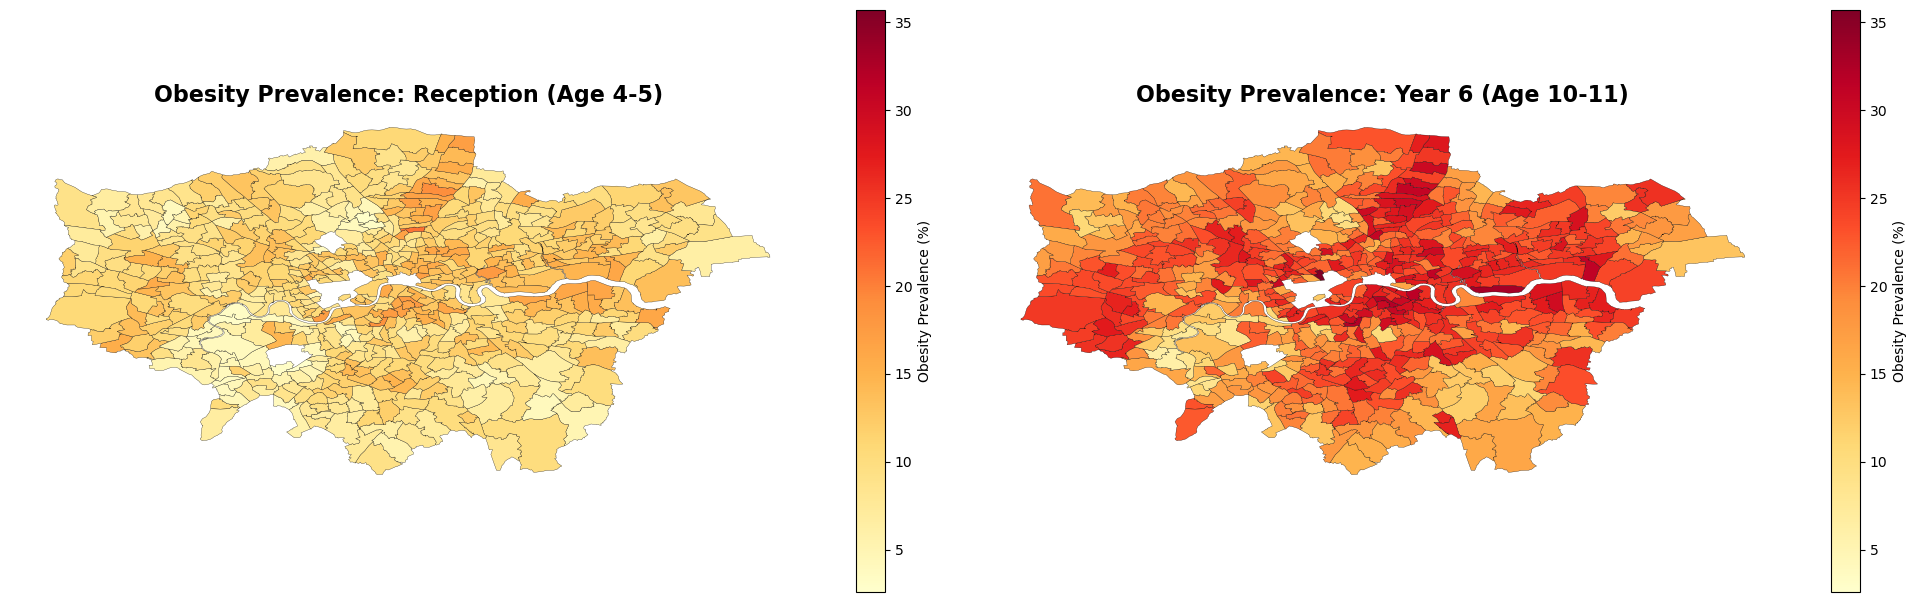

In [19]:
# Plot childhood obesity prevalance maps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

vmin = min(geo_df['Reception'].min(), geo_df['Year 6'].min())
vmax = max(geo_df['Reception'].max(), geo_df['Year 6'].max())

plot_kwds = {
    'cmap': 'YlOrRd',          # 经典的 黄-橙-红 渐变色，非常适合呈现风险/肥胖率
    'vmin': vmin,              # 统一最小刻度
    'vmax': vmax,              # 统一最大刻度
    'edgecolor': 'black',      # 区域边界线颜色
    'linewidth': 0.2,          # 边界线极细，避免喧宾夺主
    'legend': True,
    'legend_kwds': {'shrink': 0.6, 'label': 'Obesity Prevalence (%)'} # 缩小图例比例并添加标签
}

# Reception
geo_df.plot(column='Reception', ax=ax1, **plot_kwds)
ax1.set_title('Obesity Prevalence: Reception (Age 4-5)', fontsize=16, fontweight='bold')
ax1.axis('off')

# Year 6
geo_df.plot(column='Year 6', ax=ax2, **plot_kwds)
ax2.set_title('Obesity Prevalence: Year 6 (Age 10-11)', fontsize=16, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()

## Methodology

[[ go back to the top ]](#Table-of-contents)

方法一：VIF 多重共线性检验将初步选定的 30 个变量输入，设置阈值（如 VIF < 5）。筛掉高度冗余的变量，最终留下 15-20 个纯净、独立、且有代表性的特征。

方法二：普通多元线性回归 (MLR) 或 Lasso (Baseline Model)使用经过 VIF 筛选后的 15 个变量建立 MLR。因为已经去除了共线性，此时 MLR 输出的每个变量的 p-value 和系数大小都是高度可靠的。(注：既然已经用 VIF 解决了共线性，普通的 MLR 就足够作为一条优秀的基准线了，无需一定要上 Lasso。)

方法三：XGBoost / Random Forest使用同样的 15 个变量训练树模型，捕捉空间特征与肥胖率之间的复杂非线性关系，并展示其预测指标（RMSE, $R^2$）如何碾压线性的 MLR。

方法四：SHAP 模型解释深入剖析树模型的黑盒，回答 RQ2（到底哪个变量影响最大，其边际效应是什么样的）。

*[Note: a flow chart that describes the methodology is strongly encouraged - see the example below. This flow chart can be made using Microsoft powerpoint or visio or other software]*

Source: see [link](https://linkinghub.elsevier.com/retrieve/pii/S2210670722004437).

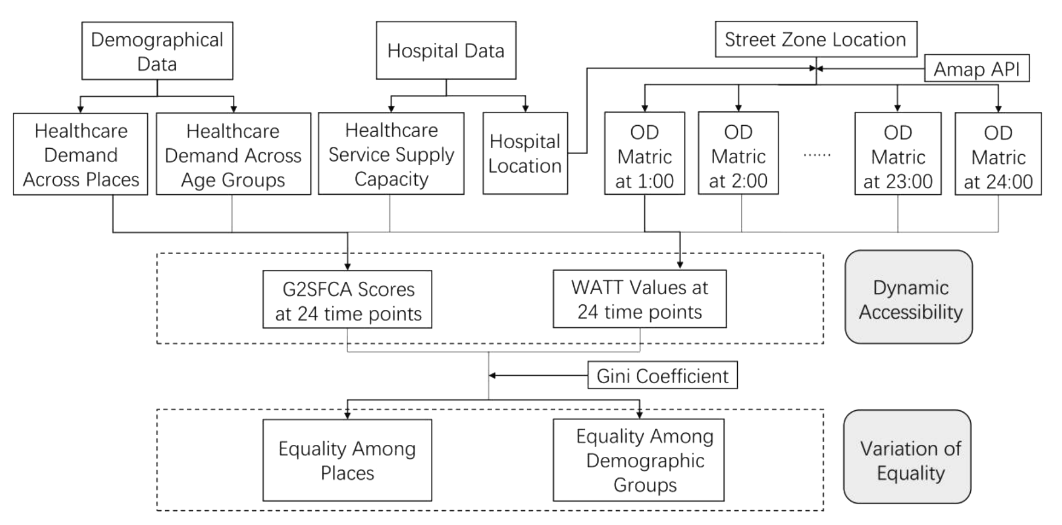

#### VIF

## Results and discussion

[[ go back to the top ]](#Table-of-contents)

## Conclusion

[[ go back to the top ]](#Table-of-contents)

In [20]:
end_time = time.time() 
run_time = end_time - start_time 
print("Total run time: ", run_time, "seconds")

Total run time:  1.560807466506958 seconds


## References

[[ go back to the top ]](#Table-of-contents)